# Clase 9: Introducción al Machine Learning
## Predicción de default en tarjetas de crédito
### Lasso + Random Forest

---

## ¿Qué es Machine Learning?

En econometría el objetivo es **inferencia**: entender la relación entre variables, estimar coeficientes, hacer pruebas de hipótesis. La pregunta es *¿cuánto afecta X a Y?*

En Machine Learning el objetivo es **predicción**: construir un modelo que, dado un conjunto de variables, prediga lo mejor posible el valor de Y para observaciones que no vio durante el entrenamiento. La pregunta es *¿cuánto va a ser Y?*

La diferencia tiene consecuencias:

| | Econometría | Machine Learning |
|---|---|---|
| Objetivo | Inferencia causal | Predicción fuera de muestra |
| Preocupación | Sesgo de los estimadores | Overfitting |
| Evaluación | R², p-valores | Accuracy, F1, AUC en test set |
| Modelo | Parsimonioso e interpretable | Puede ser una caja negra |

## El problema de hoy

Un banco en Taiwan tiene 30,000 clientes de tarjeta de crédito. Quiere saber **qué clientes van a entrar en default el mes que viene** para tomar decisiones preventivas.

Variable objetivo: `default` — 1 si el cliente no pagó, 0 si pagó.

Esto es **clasificación binaria** — el modelo predice una de dos categorías.

---
## Paso 0 — Instalación

In [1]:
%%capture
pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)

# semilla para reproducibilidad — equivale a set.seed() en R
np.random.seed(42)

print("Librerías cargadas ✓")

Librerías cargadas ✓


---
## Paso 1 — Descargar los datos

El dataset viene del UCI Machine Learning Repository — una colección pública de datasets para investigación. `fetch_ucirepo(id=350)` descarga exactamente el dataset de default de tarjetas de crédito de Taiwan (2005).

In [3]:
# fetch_ucirepo descarga el dataset directamente desde UCI
# id=350 es el identificador único de este dataset en el repositorio
dataset = fetch_ucirepo(id=350)

# el dataset viene separado en features (X) y target (y)
# features = las variables explicativas (lo que sabemos del cliente)
# targets  = lo que queremos predecir (¿defaulteó?)
X = dataset.data.features
y = dataset.data.targets

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"\nVariables disponibles:")
print(list(X.columns))

Dimensiones de X: (30000, 23)
Dimensiones de y: (30000, 1)

Variables disponibles:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


In [4]:
# ver las primeras filas
X.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [5]:
# descripción de cada variable
print(dataset.variables[['name', 'description']].to_string())

   name                 description
0    ID                        None
1    X1                   LIMIT_BAL
2    X2                         SEX
3    X3                   EDUCATION
4    X4                    MARRIAGE
5    X5                         AGE
6    X6                       PAY_0
7    X7                       PAY_2
8    X8                       PAY_3
9    X9                       PAY_4
10  X10                       PAY_5
11  X11                       PAY_6
12  X12                   BILL_AMT1
13  X13                   BILL_AMT2
14  X14                   BILL_AMT3
15  X15                   BILL_AMT4
16  X16                   BILL_AMT5
17  X17                   BILL_AMT6
18  X18                    PAY_AMT1
19  X19                    PAY_AMT2
20  X20                    PAY_AMT3
21  X21                    PAY_AMT4
22  X22                    PAY_AMT5
23  X23                    PAY_AMT6
24    Y  default payment next month


In [6]:
# dataset.variables tiene el mapeo name → description
# lo usamos para renombrar automáticamente
variables = dataset.variables

# crear diccionario {nombre_actual: descripcion}
# dropna() para ignorar filas sin descripción (como ID)
rename_dict = (
    variables[['name', 'description']]
    .dropna()
    .set_index('name')['description']
    .to_dict()
)

print("Mapeo de nombres:")
print(rename_dict)

# renombrar las columnas
X = X.rename(columns=rename_dict)
print("\nColumnas después de renombrar:")
print(X.columns.tolist())

Mapeo de nombres:
{'X1': 'LIMIT_BAL', 'X2': 'SEX', 'X3': 'EDUCATION', 'X4': 'MARRIAGE', 'X5': 'AGE', 'X6': 'PAY_0', 'X7': 'PAY_2', 'X8': 'PAY_3', 'X9': 'PAY_4', 'X10': 'PAY_5', 'X11': 'PAY_6', 'X12': 'BILL_AMT1', 'X13': 'BILL_AMT2', 'X14': 'BILL_AMT3', 'X15': 'BILL_AMT4', 'X16': 'BILL_AMT5', 'X17': 'BILL_AMT6', 'X18': 'PAY_AMT1', 'X19': 'PAY_AMT2', 'X20': 'PAY_AMT3', 'X21': 'PAY_AMT4', 'X22': 'PAY_AMT5', 'X23': 'PAY_AMT6', 'Y': 'default payment next month'}

Columnas después de renombrar:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [7]:
# ¿Cuántos clientes defaultearon?
# Esta es la primera pregunta que hay que hacerse antes de modelar:
# ¿qué tan desbalanceado está el dataset?

conteo = y.value_counts()
print("Distribución de la variable objetivo:")
print(conteo)
print(f"\nPorcentaje de defaults: {conteo[1] / len(y) * 100:.1f}%")
print(f"Porcentaje de no-defaults: {conteo[0] / len(y) * 100:.1f}%")

# Esto es importante: si el 78% no defaultea, un modelo que siempre prediga
# 'no default' tiene 78% de accuracy sin aprender nada útil
# por eso accuracy sola no es suficiente — lo vemos más adelante

Distribución de la variable objetivo:
Y
0    23364
1     6636
Name: count, dtype: int64

Porcentaje de defaults: 22.1%
Porcentaje de no-defaults: 77.9%


---
## Paso 2 — Exploración y limpieza

Los datos reales siempre tienen problemas. Este dataset tiene categorías no documentadas en EDUCATION y MARRIAGE que hay que manejar antes de modelar.

In [8]:
# estadísticos básicos de todas las columnas
# equivale a summary() en R
X.head(10)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
5,50000,1,1,2,37,0,0,0,0,0,...,57608,19394,19619,20024,2500,1815,657,1000,1000,800
6,500000,1,1,2,29,0,0,0,0,0,...,445007,542653,483003,473944,55000,40000,38000,20239,13750,13770
7,100000,2,2,2,23,0,-1,-1,0,0,...,601,221,-159,567,380,601,0,581,1687,1542
8,140000,2,3,1,28,0,0,2,0,0,...,12108,12211,11793,3719,3329,0,432,1000,1000,1000
9,20000,1,3,2,35,-2,-2,-2,-2,-1,...,0,0,13007,13912,0,0,0,13007,1122,0


In [9]:
# la documentación oficial del dataset describe estas categorías:
#
# EDUCATION: 1=posgrado, 2=universidad, 3=preparatoria, 4=otros
# MARRIAGE:  1=casado, 2=soltero, 3=otros
#
# pero los datos tienen valores no documentados que hay que investigar primero

print("Valores únicos en EDUCATION:", sorted(X['EDUCATION'].unique()))
print("Valores únicos en MARRIAGE:",  sorted(X['MARRIAGE'].unique()))
print()
print("Según la documentación oficial (Yeh, 2009):")
print("  EDUCATION debería tener solo: 1, 2, 3, 4")
print("  MARRIAGE  debería tener solo: 1, 2, 3")
print()
print("Los valores 0, 5, 6 en EDUCATION y 0 en MARRIAGE")
print("no están descritos en el paper — son probablemente errores de captura")
print("o categorías no documentadas. Los agrupamos en 'otros'.")

Valores únicos en EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Valores únicos en MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Según la documentación oficial (Yeh, 2009):
  EDUCATION debería tener solo: 1, 2, 3, 4
  MARRIAGE  debería tener solo: 1, 2, 3

Los valores 0, 5, 6 en EDUCATION y 0 en MARRIAGE
no están descritos en el paper — son probablemente errores de captura
o categorías no documentadas. Los agrupamos en 'otros'.


---
## Paso 3 — Transformaciones

Tres tipos de transformaciones que vamos a hacer:

1. **Limpiar categorías no documentadas** — EDUCATION y MARRIAGE tienen valores que no deberían existir
2. **Crear variables nuevas** — ratios y tendencias que capturan información que las variables originales no expresan directamente
3. **Transformación logarítmica** — para variables con distribuciones muy sesgadas

In [10]:
# trabajamos sobre una copia para no modificar los datos originales
df = X.copy()
df['default'] = y.values   # agregar la variable objetivo al DataFrame

# ── Limpieza de categorías ────────────────────────────────────────────────────

# ¿Qué es una lambda?
# Es una función anónima — una función que no tiene nombre y se define en una línea.
# En R escribirías: function(x) ifelse(x %in% c(1,2,3,4), x, 4)
# En Python se escribe: lambda x: x if x in [1,2,3,4] else 4
#
# La sintaxis es: lambda argumento: valor_si_true if condicion else valor_si_false
# Se lee igual que un if/else normal pero en una sola línea.
#
# .apply(función) aplica esa función a cada elemento de la columna.
# Es equivalente a usar map() o sapply() en R.
#
# Entonces esta línea dice:
# "para cada valor x en EDUCATION:
#    si x está en [1, 2, 3, 4] → déjalo igual
#    si no → reemplázalo con 4 (categoría 'otros')"

# probemos la lambda sola antes de aplicarla a toda la columna
funcion_educacion = lambda x: x if x in [1, 2, 3, 4] else 4

print("Prueba de la lambda:")
for valor in [0, 1, 2, 3, 4, 5, 6]:
    print(f"  funcion_educacion({valor}) → {funcion_educacion(valor)}")

Prueba de la lambda:
  funcion_educacion(0) → 4
  funcion_educacion(1) → 1
  funcion_educacion(2) → 2
  funcion_educacion(3) → 3
  funcion_educacion(4) → 4
  funcion_educacion(5) → 4
  funcion_educacion(6) → 4


In [11]:
# ── Variables nuevas ──────────────────────────────────────────────────────────

# 1. Ratio de utilización del crédito
#    ¿Qué fracción de su límite está usando el cliente?
#    Un cliente que usa el 95% de su límite está más expuesto que uno que usa el 20%
#    BILL_AMT1 es el estado de cuenta más reciente (septiembre)
#    np.where(condicion, valor_si_true, valor_si_false) equivale a ifelse() en R
df['ratio_utilizacion'] = np.where(
    df['LIMIT_BAL'] > 0,
    df['BILL_AMT1'] / df['LIMIT_BAL'],
    0   # evitar división entre cero
)

# 2. Promedio de retraso en los últimos 6 meses
#    PAY_0 a PAY_6 = historial de pagos (-1=pagó bien, 0=mínimo, 1=mes retraso, etc.)
#    el promedio captura el comportamiento general del cliente
cols_pay = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['promedio_retraso'] = df[cols_pay].mean(axis=1)   # axis=1 = promedio por fila

# 3. Tendencia de la deuda: ¿está subiendo o bajando?
#    BILL_AMT1 = deuda en septiembre (más reciente)
#    BILL_AMT6 = deuda en abril (más antiguo)
#    si la diferencia es positiva, la deuda creció — señal de riesgo
df['tendencia_deuda'] = df['BILL_AMT1'] - df['BILL_AMT6']

# 4. Log del límite de crédito
#    LIMIT_BAL tiene una distribución muy sesgada — hay pocos clientes
#    con límites muy altos que distorsionan los modelos lineales
#    el logaritmo comprime esa distribución
#    np.log1p(x) = log(x + 1) — el +1 evita log(0) si hubiera valores en cero
df['log_limite'] = np.log1p(df['LIMIT_BAL'])

# 5. Total pagado en los últimos 6 meses
#    PAY_AMT1 a PAY_AMT6 = montos pagados cada mes
#    la suma captura la capacidad de pago total del cliente
cols_amt = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df['total_pagado'] = df[cols_amt].sum(axis=1)

print("Variables nuevas creadas:")
nuevas = ['ratio_utilizacion', 'promedio_retraso', 'tendencia_deuda',
          'log_limite', 'total_pagado']
df[nuevas].describe().round(3)

Variables nuevas creadas:


,ratio_utilizacion,promedio_retraso,tendencia_deuda,log_limite,total_pagado
count,30000.000,30000.000,30000.000,30000.000,30000.000
mean,0.424,-0.182,12351.570,11.663,31651.393
std,0.411,0.982,43922.422,0.941,60827.678
min,-0.620,-2.000,-428791.000,9.210,0.000
25%,0.022,-0.833,-2963.000,10.820,6679.750
50%,0.314,0.000,923.000,11.849,14383.000
75%,0.830,0.000,19793.750,12.388,33503.500
max,6.455,6.000,708323.000,13.816,3764066.000


---
## Paso 4 — Preparar para modelar

### Train/test split

En ML nunca evaluamos el modelo en los mismos datos con los que entrenamos — eso sería hacer trampa. El modelo puede memorizar los datos de entrenamiento (overfitting) y parecer muy bueno sin serlo realmente.

La solución: separar los datos en **train** (para entrenar) y **test** (para evaluar). El modelo nunca ve el test set durante el entrenamiento.

In [12]:
# definir las variables que vamos a usar en los modelos
# incluimos las originales + las nuevas que creamos
FEATURES = [
    # variables originales relevantes
    'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    # variables nuevas
    'log_limite', 'ratio_utilizacion', 'promedio_retraso',
    'tendencia_deuda', 'total_pagado'
]

X_model = df[FEATURES]
y_model = df['default']

# train_test_split divide los datos aleatoriamente
# test_size=0.2 → 20% para test, 80% para train
# stratify=y_model → mantiene la misma proporción de defaults en ambos sets
#   sin stratify, el test podría tener más o menos defaults que el train por azar
# random_state=42 → semilla para reproducibilidad

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size    = 0.2,
    stratify     = y_model,
    random_state = 42
)

print(f"Train: {X_train.shape[0]} observaciones ({X_train.shape[0]/len(X_model)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} observaciones  ({X_test.shape[0]/len(X_model)*100:.0f}%)")
print(f"\nPorcentaje de defaults en train: {y_train.mean()*100:.1f}%")
print(f"Porcentaje de defaults en test:  {y_test.mean()*100:.1f}%")

Train: 24000 observaciones (80%)
Test:  6000 observaciones  (20%)

Porcentaje de defaults en train: 22.1%
Porcentaje de defaults en test:  22.1%


In [13]:
# ── Escalado de variables ─────────────────────────────────────────────────────
#
# Los modelos lineales como Lasso son sensibles a la escala de las variables
# Si AGE va de 20 a 80 y LIMIT_BAL va de 10,000 a 1,000,000,
# el modelo va a penalizar más a LIMIT_BAL solo por ser un número más grande
#
# StandardScaler estandariza cada variable a media=0 y desviación estándar=1
# z = (x - media) / desviación_estándar
# equivale a scale() en R
#
# IMPORTANTE: ajustamos el scaler SOLO con train y lo aplicamos a ambos
# Si ajustamos con test, estaríamos filtrando información del test al train

scaler = StandardScaler()

# .fit_transform() ajusta el scaler y transforma en un solo paso
X_train_scaled = scaler.fit_transform(X_train)

# .transform() solo transforma — usa los parámetros del fit anterior
X_test_scaled  = scaler.transform(X_test)

print("Variables escaladas ✓")
print(f"Media de AGE en train (debe ser ~0): {X_train_scaled[:, 3].mean():.4f}")
print(f"Std de AGE en train (debe ser ~1):   {X_train_scaled[:, 3].std():.4f}")

Variables escaladas ✓
Media de AGE en train (debe ser ~0): -0.0000
Std de AGE en train (debe ser ~1):   1.0000


---
## Paso 5 — Lasso (Regresión Logística con regularización L1)

### ¿Qué es Lasso?

Una regresión logística estima la probabilidad de un evento binario. Lasso agrega una **penalización L1** que empuja los coeficientes de las variables menos importantes hacia cero, realizando **selección automática de variables**.

A diferencia de una regresión lineal (OLS), donde existe una solución matemática directa para estimar los coeficientes, la regresión logística se estima mediante un **algoritmo iterativo**. En cada iteración, el algoritmo ajusta ligeramente los coeficientes para reducir el error de predicción hasta encontrar la mejor solución posible.

El modelo minimiza la siguiente función:

$$
\text{Loss} + \lambda \sum_{j=1}^{p} |\beta_j|
$$

donde:

- **Loss**: error de predicción (log-loss de la regresión logística).
- **$\lambda$**: intensidad de la penalización.
- **$\sum |\beta_j|$**: penalización sobre el tamaño de los coeficientes.

¿Por qué agregar esta penalización?

En Machine Learning suele haber muchas variables y algunas solo capturan **ruido**. Si el modelo intenta ajustar incluso ese ruido, aparece el **overfitting (sobreajuste)**: el modelo funciona muy bien sobre los datos de entrenamiento, pero pierde capacidad para predecir datos nuevos.

Lasso combate este problema reduciendo o eliminando las variables que aportan poca información, obteniendo modelos más simples y con mejor capacidad de generalización.

En `scikit-learn`, la penalización se controla mediante:

$$
C=\frac{1}{\lambda}
$$

- **C pequeño** → mayor regularización.
- **C grande** → menor regularización.

In [14]:
# LogisticRegression con penalty='l1' es Lasso logístico
# solver='liblinear' → el único solver que soporta L1 en sklearn
# max_iter=1000 → máximo de iteraciones para que el algoritmo converja

lasso = LogisticRegression(
    penalty    = 'l1',
    C          = 0.01,
    solver     = 'liblinear',
    max_iter   = 1000,
    random_state = 42
)

# .fit() entrena el modelo — equivale a lm() o glm() en R
lasso.fit(X_train_scaled, y_train)

print("Modelo Lasso entrenado ✓")

Modelo Lasso entrenado ✓


In [15]:
# ¿Qué variables seleccionó Lasso?
# Los coeficientes en cero fueron eliminados por la penalización

coeficientes = pd.Series(
    lasso.coef_[0],    # .coef_ contiene los coeficientes estimados
    index=FEATURES
).sort_values(key=abs, ascending=False)   # ordenar por valor absoluto

print("Coeficientes Lasso (0 = variable eliminada):")
print(coeficientes.round(4))
print(f"\nVariables eliminadas: {(coeficientes == 0).sum()} de {len(FEATURES)}")

Coeficientes Lasso (0 = variable eliminada):
PAY_0                0.6166
log_limite          -0.2054
total_pagado        -0.1699
ratio_utilizacion   -0.1215
promedio_retraso     0.1143
PAY_2                0.0765
PAY_3                0.0593
EDUCATION           -0.0510
AGE                  0.0505
MARRIAGE            -0.0466
SEX                 -0.0231
tendencia_deuda     -0.0036
PAY_6                0.0000
PAY_4                0.0000
PAY_5                0.0000
dtype: float64

Variables eliminadas: 3 de 15


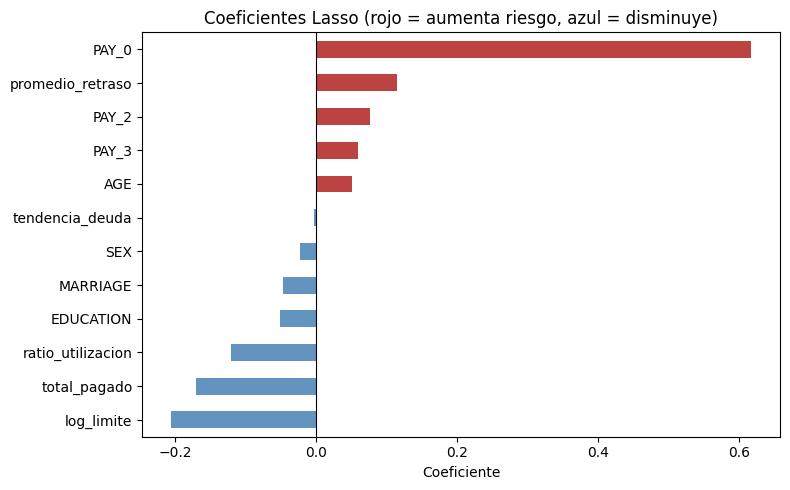

In [16]:
# visualizar los coeficientes
coef_no_cero = coeficientes[coeficientes != 0].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colores = ['firebrick' if v > 0 else 'steelblue' for v in coef_no_cero.values]
coef_no_cero.plot(kind='barh', ax=ax, color=colores, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes Lasso (rojo = aumenta riesgo, azul = disminuye)', fontsize=12)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

---
## Paso 6 — Evaluar el modelo: ¿por qué el accuracy no es suficiente?

Una vez entrenado el modelo, debemos evaluar qué tan bien predice. La métrica más conocida es el **accuracy**, que mide el porcentaje de observaciones clasificadas correctamente.

El problema es que nuestro dataset está **desbalanceado**: cerca del **78% de los clientes no hace default**. Un modelo que siempre predijera "no default" tendría un **78% de accuracy**, aunque nunca detectara un cliente riesgoso. Por eso, en clasificación no basta con mirar el accuracy.

### Matriz de confusión

La matriz de confusión resume los aciertos y errores del modelo:

|  | Predijo NO default | Predijo SÍ default |
|---|---|---|
| **Real: NO default** | ✓ Verdadero Negativo (TN) | ✗ Falso Positivo (FP) |
| **Real: SÍ default** | ✗ Falso Negativo (FN) | ✓ Verdadero Positivo (TP) |

### Precision y Recall

La regresión logística predice una **probabilidad**. Luego se fija un **umbral** (por ejemplo, 0.5): si la probabilidad es mayor al umbral, el modelo predice **default**; si es menor, predice **no default**.

- **Precision:** de los clientes que el modelo predijo como default, ¿cuántos realmente hicieron default?

$$
\text{Precision}=\frac{TP}{TP+FP}
$$

- **Recall:** de los clientes que realmente hicieron default, ¿a cuántos logró detectar?

$$
\text{Recall}=\frac{TP}{TP+FN}
$$

Al bajar el umbral aumenta el **recall**, pero también suelen aumentar los **falsos positivos**, reduciendo la **precision**. El **F1-score** resume este equilibrio:

$$
F1=2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}
$$

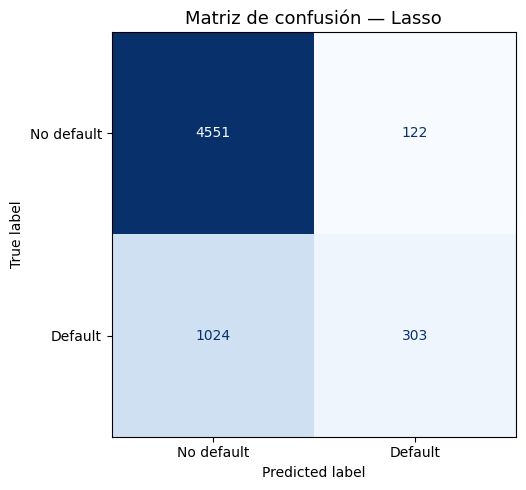


Verdaderos Negativos (TN):  4551  (97.4% de los no-defaults) — predijo bien ✓
Falsos Positivos     (FP):   122  (2.6% de los no-defaults) — alarma falsa ✗
Falsos Negativos     (FN):  1024  (77.2% de los defaults)    — default no detectado ✗ (más costoso)
Verdaderos Positivos (TP):   303  (22.8% de los defaults)    — predijo bien ✓

De cada 100 clientes que SÍ defaultearon, el modelo detectó 23


In [17]:
# .predict() predice la clase (0 o 1) para cada observación del test set
y_pred_lasso = lasso.predict(X_test_scaled)

# .predict_proba() predice la PROBABILIDAD de cada clase
# [:, 1] toma la probabilidad de la clase 1 (default)
y_prob_lasso = lasso.predict_proba(X_test_scaled)[:, 1]

# matriz de confusión
cm_lasso = confusion_matrix(y_test, y_pred_lasso)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lasso,
                               display_labels=['No default', 'Default'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusión — Lasso', fontsize=13)
plt.tight_layout()
plt.show()

# totales para calcular porcentajes
total     = cm_lasso.sum()
total_neg = cm_lasso[0].sum()   # todos los que realmente NO defaultearon
total_pos = cm_lasso[1].sum()   # todos los que realmente SÍ defaultearon

tn = cm_lasso[0, 0]
fp = cm_lasso[0, 1]
fn = cm_lasso[1, 0]
tp = cm_lasso[1, 1]

print(f"\nVerdaderos Negativos (TN): {tn:>5}  ({tn/total_neg*100:.1f}% de los no-defaults) — predijo bien ✓")
print(f"Falsos Positivos     (FP): {fp:>5}  ({fp/total_neg*100:.1f}% de los no-defaults) — alarma falsa ✗")
print(f"Falsos Negativos     (FN): {fn:>5}  ({fn/total_pos*100:.1f}% de los defaults)    — default no detectado ✗ (más costoso)")
print(f"Verdaderos Positivos (TP): {tp:>5}  ({tp/total_pos*100:.1f}% de los defaults)    — predijo bien ✓")
print(f"\nDe cada 100 clientes que SÍ defaultearon, el modelo detectó {tp/total_pos*100:.0f}")

In [18]:
# reporte completo de métricas
# classification_report calcula precision, recall y f1 para cada clase
print("Reporte de clasificación — Lasso:")
print(classification_report(y_test, y_pred_lasso,
                             target_names=['No default', 'Default']))

# AUC-ROC: mide la capacidad discriminativa del modelo
# 0.5 = modelo aleatorio, 1.0 = modelo perfecto
auc_lasso = roc_auc_score(y_test, y_prob_lasso)
print(f"AUC-ROC: {auc_lasso:.4f}")

Reporte de clasificación — Lasso:
              precision    recall  f1-score   support

  No default       0.82      0.97      0.89      4673
     Default       0.71      0.23      0.35      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

AUC-ROC: 0.7074


In [19]:
# ── Demostrar la trampa del accuracy ──────────────────────────────────────────
# un modelo que siempre predice 'no default' tiene accuracy alta pero es inútil

y_siempre_cero = np.zeros(len(y_test))   # siempre predice no default

from sklearn.metrics import accuracy_score

acc_lasso     = accuracy_score(y_test, y_pred_lasso)
acc_cero      = accuracy_score(y_test, y_siempre_cero)
f1_lasso      = f1_score(y_test, y_pred_lasso)
f1_cero       = f1_score(y_test, y_siempre_cero)

print("Comparación de métricas:\n")
print(f"{'Modelo':<30} {'Accuracy':>10} {'F1 (default)':>14}")
print("-" * 56)
print(f"{'Lasso':<30} {acc_lasso:>10.3f} {f1_lasso:>14.3f}")
print(f"{'Siempre predice no-default':<30} {acc_cero:>10.3f} {f1_cero:>14.3f}")
print()
print("El modelo 'siempre no-default' tiene accuracy similar pero F1=0")
print("No detecta ningún default — completamente inútil para el banco")

Comparación de métricas:

Modelo                           Accuracy   F1 (default)
--------------------------------------------------------
Lasso                               0.809          0.346
Siempre predice no-default          0.779          0.000

El modelo 'siempre no-default' tiene accuracy similar pero F1=0
No detecta ningún default — completamente inútil para el banco


---
## Paso 7 — Árboles de decisión: verlos por dentro

Antes de entender el Random Forest tenemos que entender su **ladrillo básico**: el árbol de decisión.

Un árbol de decisión divide a los clientes haciendo **preguntas binarias** encadenadas:

- *¿`PAY_0` > 1?* → sí / no
- dentro de cada rama, otra pregunta: *¿`log_limite` < 11?* → sí / no
- … y así hasta llegar a una **hoja**, que predice una clase.

Es literalmente un diagrama de flujo que el algoritmo **aprende solo** a partir de los datos. La gran ventaja frente a Lasso es que puede capturar relaciones **no lineales** y **interacciones** entre variables sin que se lo pidamos.

Lo mejor de un árbol individual es que se puede **dibujar y leer**. Vamos a entrenar uno pequeño (profundidad 3) y mirarlo por dentro.


In [20]:
# ── Imports para toda esta parte de la clase ─────────────────────────────────
# Un "import" trae funciones que otras personas ya programaron, para no
# reescribirlas nosotros. Cada línea trae una herramienta distinta.

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
#   DecisionTreeClassifier → un árbol de decisión (para clasificar)
#   DecisionTreeRegressor  → un árbol para predecir números (lo usamos en un demo)
#   plot_tree              → una FUNCIÓN que dibuja el árbol

from sklearn.datasets    import make_moons          # datos de juguete en forma de 2 lunas
from sklearn.calibration import calibration_curve   # mide si las probabilidades son confiables
from sklearn.metrics     import roc_curve, f1_score # curva ROC y métrica F1

print("Imports listos ✓")

Imports listos ✓


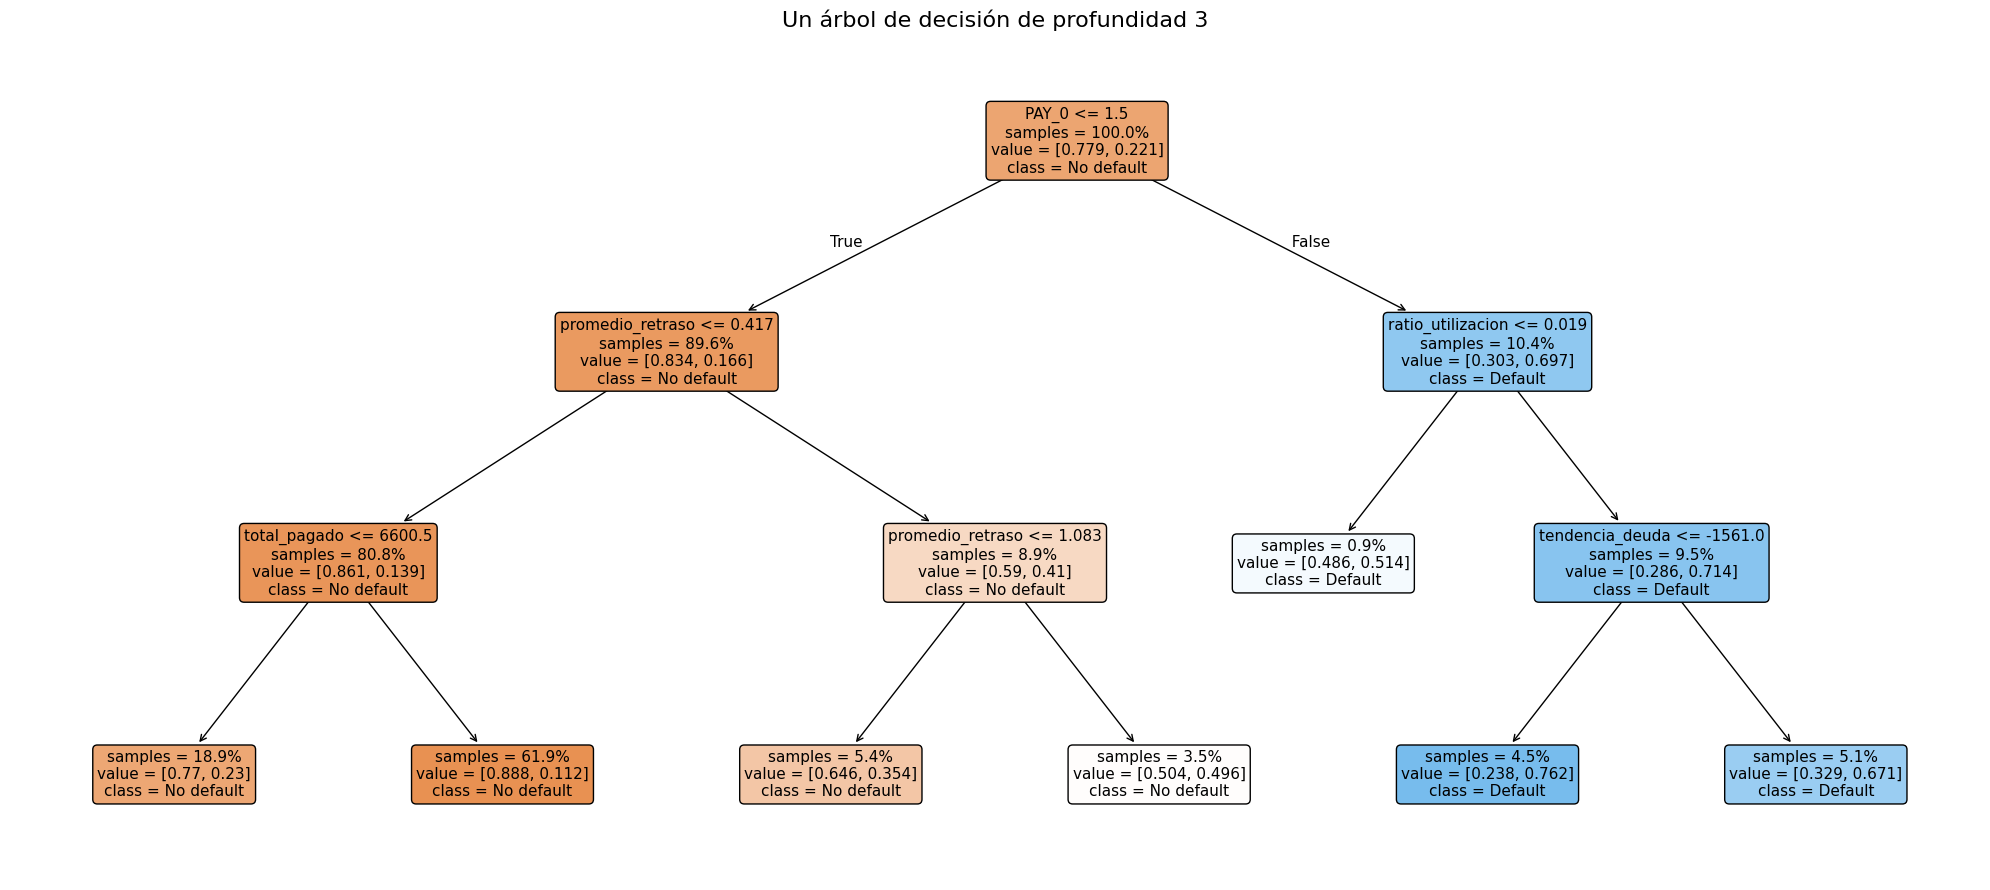

In [21]:
# ── Un árbol pequeño que SÍ se puede leer ────────────────────────────────────
# DecisionTreeClassifier(...) crea el modelo. Lo que va dentro del paréntesis
# con nombre (max_depth=3, ...) son "argumentos con nombre": le dicen al árbol
# cómo comportarse.
arbol_simple = DecisionTreeClassifier(
    max_depth        = 3,     # como mucho 3 preguntas encadenadas (para que quepa en pantalla)
    min_samples_leaf = 200,   # cada hoja debe agrupar al menos 200 clientes
    random_state     = 42     # semilla: hace el resultado reproducible
)

# .fit(X, y) ENTRENA el modelo. Es un "método": una función que vive dentro
# del objeto arbol_simple. Los árboles NO necesitan escalado → usamos X_train.
arbol_simple.fit(X_train, y_train)

# plot_tree es una FUNCIÓN: recibe el árbol ya entrenado y lo dibuja.
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    arbol_simple,
    feature_names = FEATURES,                   # nombres de las variables
    class_names   = ['No default', 'Default'],  # nombres de las 2 clases
    filled        = True,     # colorea cada caja según la clase que predice
    rounded       = True,
    proportion    = True,     # muestra proporciones (%) en vez de conteos
    impurity      = False,    # ocultamos el "gini" para que se lea más fácil
    fontsize      = 11,
    ax            = ax
)
ax.set_title('Un árbol de decisión de profundidad 3', fontsize=16)
plt.tight_layout()
plt.show()

# CÓMO LEERLO (de arriba hacia abajo):
#   - Arriba está la primera pregunta (casi siempre sobre PAY_0, el atraso más
#     reciente: la variable que más ayuda a predecir el default).
#   - Rama izquierda = "la condición se cumple";  derecha = "no se cumple".
#   - El color de la hoja dice hacia qué clase se inclina el grupo:
#     naranja = tiende a default, azul = tiende a pagar.

### La misma idea, dibujada como un "mapa"

Otra forma de ver qué hace un árbol es pintar su **frontera de decisión**: coloreamos todo el plano según lo que el modelo predeciría en cada punto.

Para que se vea clarísimo usamos un dataset de juguete con forma de **dos lunas** (una clase naranja, otra azul) con algo de ruido. Comparamos tres modelos:

1. un **árbol simple** (poca profundidad) → fronteras rectas, se queda corto,
2. un **árbol profundo** (sin límite) → crea *islas* alrededor de puntos sueltos: eso es **overfitting**,
3. un **Random Forest** → promedia muchos árboles y recupera una frontera suave.


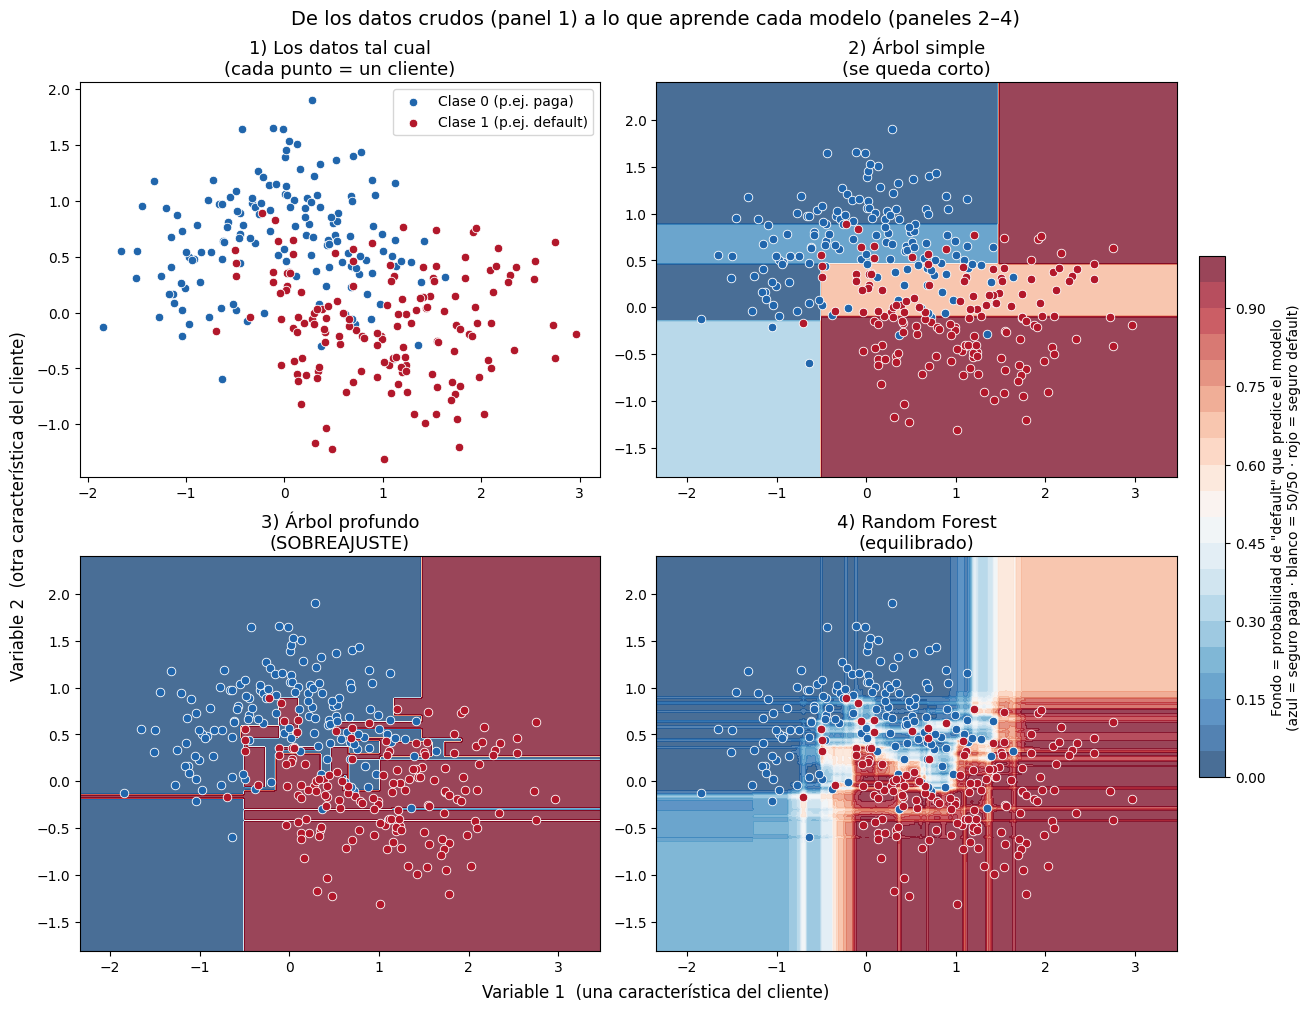

In [22]:
# ── De los datos crudos a lo que aprende cada modelo ─────────────────────────

# make_moons crea un dataset de juguete: 2 variables (2 columnas) y una clase
# (0 o 1) por punto. Devuelve DOS cosas y las "desempaquetamos" con una coma.
X_luna, y_luna = make_moons(n_samples=300, noise=0.35, random_state=42)

# Separamos los puntos por clase con una "máscara booleana"
# (y_luna == 0 es una lista de True/False):
es_clase0 = (y_luna == 0)   # imagina: "clientes que pagan"
es_clase1 = (y_luna == 1)   # imagina: "clientes en default"

# Malla: una cuadrícula de puntos que cubre todo el plano, para pintar el fondo.
x_min, x_max = X_luna[:, 0].min() - 0.5, X_luna[:, 0].max() + 0.5
y_min, y_max = X_luna[:, 1].min() - 0.5, X_luna[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
malla = np.c_[xx.ravel(), yy.ravel()]   # np.c_ pega las 2 coordenadas → lista de puntos (x, y)

# Una FUNCIÓN corta para dibujar los puntos (los MISMOS en los 4 paneles), así
# no repetimos el código. 'def' la define; aquí no devuelve nada, solo dibuja.
def dibuja_puntos(ax):
    ax.scatter(X_luna[es_clase0, 0], X_luna[es_clase0, 1], c='#2166ac',
               edgecolors='white', s=38, linewidths=0.6, label='Clase 0 (p.ej. paga)')
    ax.scatter(X_luna[es_clase1, 0], X_luna[es_clase1, 1], c='#b2182b',
               edgecolors='white', s=38, linewidths=0.6, label='Clase 1 (p.ej. default)')

# Lista de TUPLAS (titulo, modelo) con los 3 modelos a comparar.
modelos = [
    ('2) Árbol simple\n(se queda corto)', DecisionTreeClassifier(max_depth=3,     random_state=42)),
    ('3) Árbol profundo\n(SOBREAJUSTE)',  DecisionTreeClassifier(max_depth=None,   random_state=42)),
    ('4) Random Forest\n(equilibrado)',   RandomForestClassifier(n_estimators=200, random_state=42)),
]

# subplots(2, 2) crea una rejilla de 4 ejes; .ravel() la vuelve una lista simple.
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
axes = axes.ravel()

# ---- Panel 1: LOS DATOS TAL CUAL (sin modelo, fondo blanco) ----
dibuja_puntos(axes[0])
axes[0].set_title('1) Los datos tal cual\n(cada punto = un cliente)', fontsize=13)
axes[0].legend(loc='upper right', fontsize=10)

# ---- Paneles 2-4: cada modelo pinta el fondo con su predicción ----
# zip empareja cada eje (ax) con cada tupla (titulo, modelo).
for ax, (titulo, modelo) in zip(axes[1:], modelos):
    modelo.fit(X_luna, y_luna)                                # entrena el modelo
    Z = modelo.predict_proba(malla)[:, 1].reshape(xx.shape)   # prob. de clase 1 en cada punto
    im = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.75, vmin=0, vmax=1)  # fondo
    dibuja_puntos(ax)                                         # los mismos puntos encima
    ax.set_title(titulo, fontsize=13)

# ¿Qué hay en cada eje? Una sola etiqueta para toda la figura.
fig.supxlabel('Variable 1  (una característica del cliente)', fontsize=12)
fig.supylabel('Variable 2  (otra característica del cliente)', fontsize=12)
fig.suptitle('De los datos crudos (panel 1) a lo que aprende cada modelo (paneles 2–4)', fontsize=14)

# Barra de color: explica qué significa el color del fondo de los paneles 2-4.
cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.6, pad=0.02)
cbar.set_label('Fondo = probabilidad de "default" que predice el modelo\n'
               '(azul = seguro paga · blanco = 50/50 · rojo = seguro default)', fontsize=10)

plt.show()

---
## Paso 8 — Overfitting

**Overfitting (sobreajuste)** es el enemigo número uno del Machine Learning:

> el modelo aprende **el ruido** del training set en lugar del **patrón general**, y por eso predice genial en los datos que ya vio pero mal en datos nuevos.

Con un árbol es facilísimo provocarlo: basta dejarlo crecer mucho (`max_depth` grande). Un árbol muy profundo puede crear una hoja para cada cliente y clasificar el training **perfecto**… sin haber aprendido nada útil.

La forma estándar de detectarlo es medir el desempeño **en train y en test a la vez** mientras subimos la complejidad. Eso hace la siguiente gráfica.


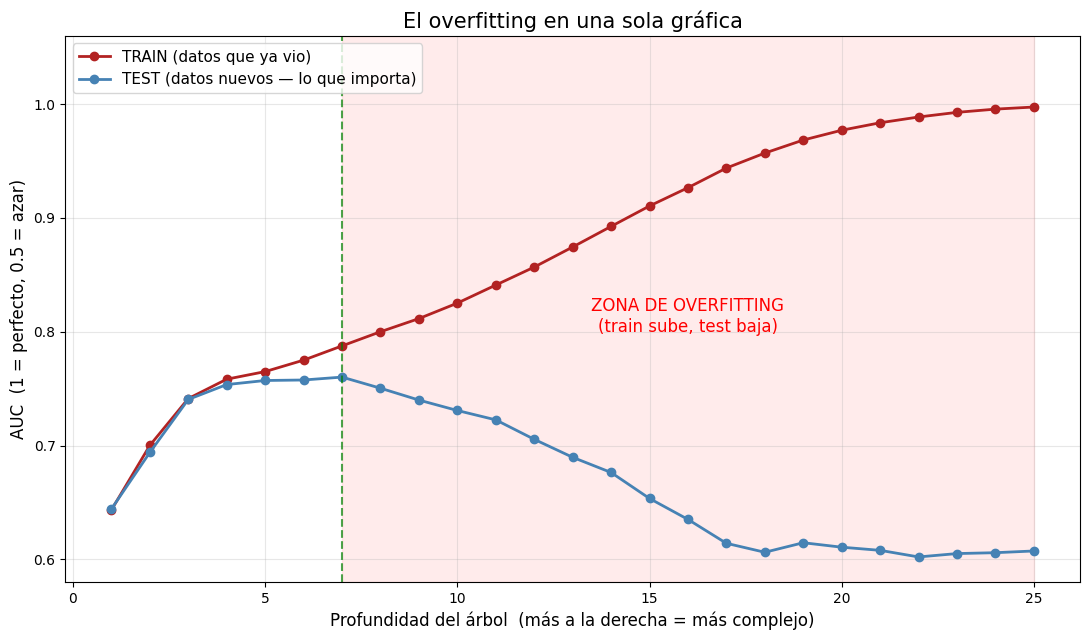

En TRAIN el AUC sube hasta 1.00: el árbol memoriza.
En TEST toca techo en depth=7 y luego baja. Esa brecha ES el overfitting.


In [23]:
# ── La curva del overfitting ─────────────────────────────────────────────────
# Idea: entrenar árboles cada vez MÁS profundos y medir qué tan bien predicen
# en train (datos que ya vieron) y en test (datos nuevos).

profundidades = range(1, 26)     # range(1, 26) = 1, 2, 3, ..., 25
auc_train = []                   # lista vacía; la llenaremos dentro del for
auc_test  = []

# Un for prueba cada profundidad. Cada vuelta entrena un árbol nuevo.
for d in profundidades:
    arbol = DecisionTreeClassifier(max_depth=d, random_state=42)
    arbol.fit(X_train, y_train)
    # predict_proba(...) da probabilidades; [:, 1] toma la columna de la clase 1.
    # roc_auc_score compara esas probabilidades con la verdad y devuelve el AUC.
    # .append(...) agrega el resultado al final de la lista.
    auc_train.append(roc_auc_score(y_train, arbol.predict_proba(X_train)[:, 1]))
    auc_test .append(roc_auc_score(y_test,  arbol.predict_proba(X_test )[:, 1]))

# np.argmax devuelve la POSICIÓN del valor más alto de test → la mejor profundidad.
mejor = list(profundidades)[int(np.argmax(auc_test))]

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(list(profundidades), auc_train, 'o-', color='firebrick', lw=2,
        label='TRAIN (datos que ya vio)')
ax.plot(list(profundidades), auc_test,  'o-', color='steelblue', lw=2,
        label='TEST (datos nuevos — lo que importa)')

# línea vertical en el punto dulce, con la etiqueta ARRIBA para que no encime
ax.axvline(mejor, color='green', ls='--', alpha=0.7)

# sombreamos la zona de overfitting y ponemos el texto EN EL HUECO entre las curvas
ax.axvspan(mejor, 25, alpha=0.08, color='red')
ax.text((mejor + 25) / 2, 0.80, 'ZONA DE OVERFITTING\n(train sube, test baja)',
        ha='center', color='red', fontsize=12)

ax.set_xlabel('Profundidad del árbol  (más a la derecha = más complejo)', fontsize=12)
ax.set_ylabel('AUC  (1 = perfecto, 0.5 = azar)', fontsize=12)
ax.set_title('El overfitting en una sola gráfica', fontsize=15)
ax.legend(fontsize=11, loc='upper left')      # arriba-izquierda: zona vacía
ax.set_ylim(0.58, 1.06); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"En TRAIN el AUC sube hasta {max(auc_train):.2f}: el árbol memoriza.")
print(f"En TEST toca techo en depth={mejor} y luego baja. Esa brecha ES el overfitting.")

**Cómo se lee — es la idea central de la clase de hoy:**

- La línea **roja (train)** sólo sube: dándole más profundidad, el árbol siempre memoriza mejor lo que ya vio. Un AUC de train cercano a 1.0 **no es buena noticia**, es una alarma.
- La línea **azul (test)** es la que importa: sube, llega a un máximo (el *punto dulce*) y después **cae**.
- La **distancia entre ambas líneas** es la magnitud del overfitting.

Todo el trabajo de un buen modelo es **cerrar esa brecha**. Dos formas: **regularizar** (lo hicimos con Lasso y su `C`), o **promediar muchos modelos** para cancelar el ruido → eso es el **Random Forest**.


---
## Paso 9 — ¿Qué es un Random Forest?

Un árbol solo tiene **alta varianza**: cambias un poco los datos y cambia mucho. La idea del Random Forest es genial por lo simple:

> Si un árbol es inestable, entrena **cientos** de árboles distintos y quédate con el **promedio** de sus votos.

Los errores de un árbol se cancelan con los de otro. Esta técnica se llama **bagging**. Para que los árboles sean **distintos**, se mete aleatoriedad de dos formas:

1. **Bootstrap:** cada árbol se entrena con una muestra **aleatoria con reemplazo** del training.
2. **Variables aleatorias:** en cada split, el árbol sólo elige entre un **subconjunto aleatorio** de variables.

El diagrama de abajo resume el proceso.


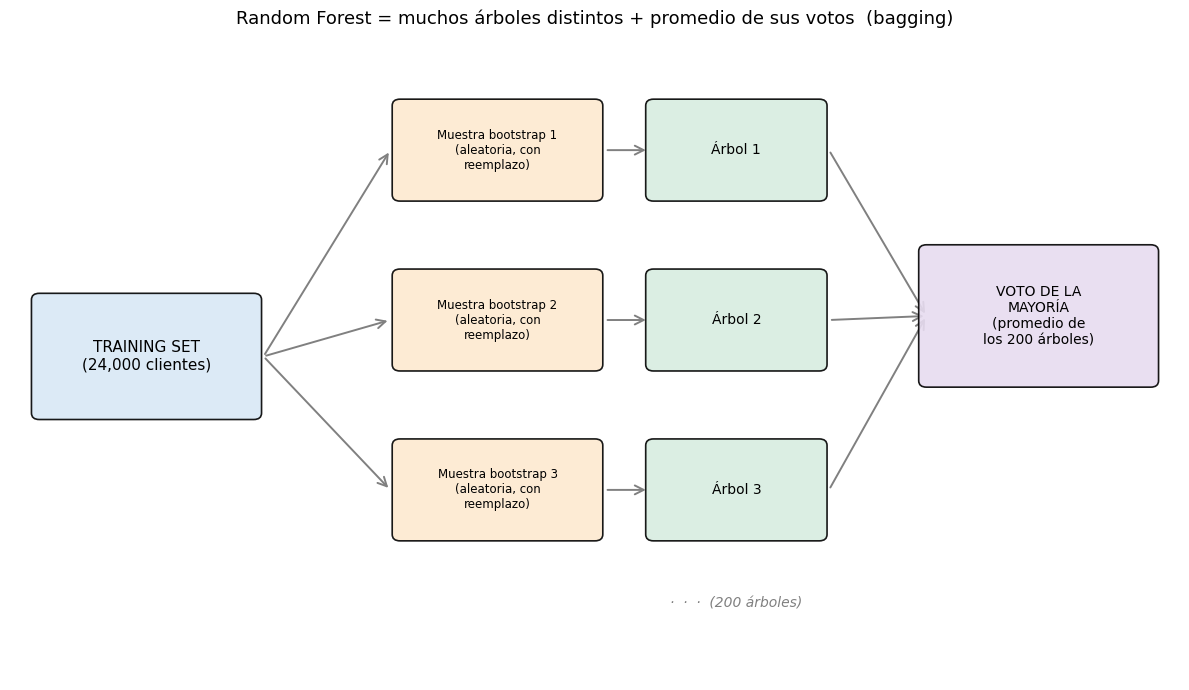

In [24]:
# Este bloque SOLO dibuja el esquema (no entrena nada). Puedes quedarte con la
# imagen sin leer el detalle del código de dibujo.
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12); ax.set_ylim(0, 8); ax.axis('off')

def caja(x, y, w, h, texto, color, fs=10):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                 fc=color, ec='black', lw=1.2, alpha=0.9))
    ax.text(x + w/2, y + h/2, texto, ha='center', va='center', fontsize=fs)

def flecha(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2),
                 arrowstyle='->', mutation_scale=16, color='gray', lw=1.4))

caja(0.3, 3.3, 2.2, 1.4, 'TRAINING SET\n(24,000 clientes)', '#d9e8f5', 11)
alturas = [6.0, 3.9, 1.8]
for i, yy in enumerate(alturas):
    caja(4.0, yy, 2.0, 1.1, f'Muestra bootstrap {i+1}\n(aleatoria, con\nreemplazo)', '#fde9d0', 8.5)
    flecha(2.6, 4.0, 3.9, yy + 0.55)
    caja(6.6, yy, 1.7, 1.1, f'Árbol {i+1}', '#d7ede0', 10)
    flecha(6.1, yy + 0.55, 6.55, yy + 0.55)
    flecha(8.4, yy + 0.55, 9.4, 4.5)
ax.text(7.45, 0.9, '·  ·  ·  (200 árboles)', ha='center', fontsize=10, style='italic', color='gray')
caja(9.4, 3.7, 2.3, 1.6, 'VOTO DE LA\nMAYORÍA\n(promedio de\nlos 200 árboles)', '#e7dcf0', 10)
ax.set_title('Random Forest = muchos árboles distintos + promedio de sus votos  (bagging)', fontsize=13)
plt.tight_layout()
plt.show()

### Ahora sí: entrenamos el Random Forest sobre nuestros clientes

Ya con la intuición clara, entrenamos el bosque real sobre el problema del banco. Los hiperparámetros son justo los que controlan el overfitting que acabamos de ver.


In [25]:
# Cada línea dentro del paréntesis es un "argumento con nombre" (nombre = valor):
# n_estimators     = número de árboles del bosque (más = más estable, más lento)
# max_depth        = profundidad máxima de CADA árbol (limita el overfitting)
# min_samples_leaf = mínimo de clientes por hoja (evita hojas de 1 cliente)
# n_jobs = -1      = usa todos los núcleos del procesador (entrena en paralelo)
rf = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 15,
    min_samples_leaf = 10,
    n_jobs           = -1,
    random_state     = 42
)

# Random Forest NO necesita escalado → usamos X_train (sin escalar), no X_train_scaled.
rf.fit(X_train, y_train)

print("Random Forest entrenado ✓  (200 árboles)")

Random Forest entrenado ✓  (200 árboles)


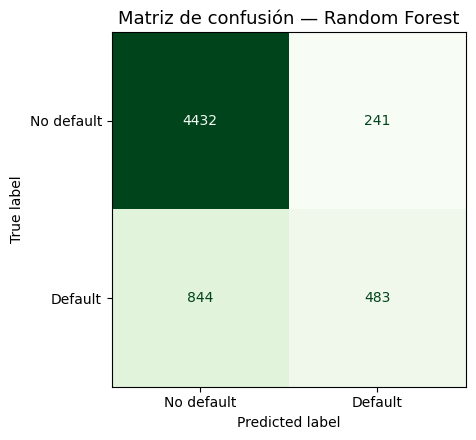

F1 (default) — Random Forest: 0.471


In [26]:
# ── Evaluar el Random Forest ─────────────────────────────────────────────────
# .predict()       → devuelve la CLASE (0 o 1) de cada cliente del test.
# .predict_proba() → devuelve PROBABILIDADES. Es una matriz de 2 columnas
#                    [prob de 0, prob de 1]; con [:, 1] tomamos la de default.
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Matriz de confusión: aciertos y errores en una tabla visual.
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix = confusion_matrix(y_test, y_pred_rf),
    display_labels   = ['No default', 'Default']
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de confusión — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

# Nos quedamos con UNA sola métrica de calidad: el F1 de la clase "default".
# (F1 combina precision y recall en un número; ya vimos por qué en el Paso 6.)
f1_rf = f1_score(y_test, y_pred_rf)
print(f"F1 (default) — Random Forest: {f1_rf:.3f}")

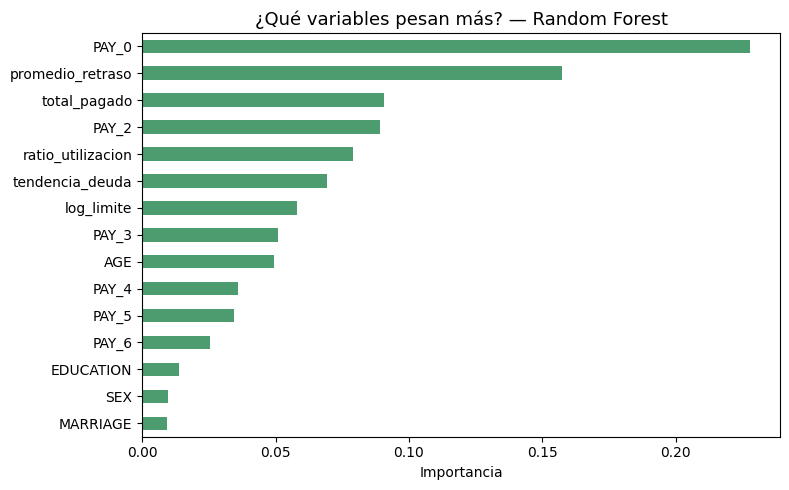

In [27]:
# ── ¿Qué variables usa más el bosque? ────────────────────────────────────────
# rf.feature_importances_ es un array con un número por variable.
# pd.Series(valores, index=nombres) los junta con sus nombres para poder graficar.
importancias = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind='barh', ax=ax, color='seagreen', alpha=0.85)
ax.set_title('¿Qué variables pesan más? — Random Forest', fontsize=13)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()


---
## Paso 10 — La curva ROC, entendida a fondo

Un modelo no entrega un "sí/no", sino una **probabilidad** de default. Para decidir, fijamos un **umbral**:

$$\text{si } P(\text{default}) \ge \text{umbral} \Rightarrow \text{predice DEFAULT}$$

El umbral **lo elegimos nosotros**, y esa elección es un trade-off. La curva ROC es el mapa de **todos los umbrales a la vez**. Empecemos mirando las **probabilidades** que produce el modelo.


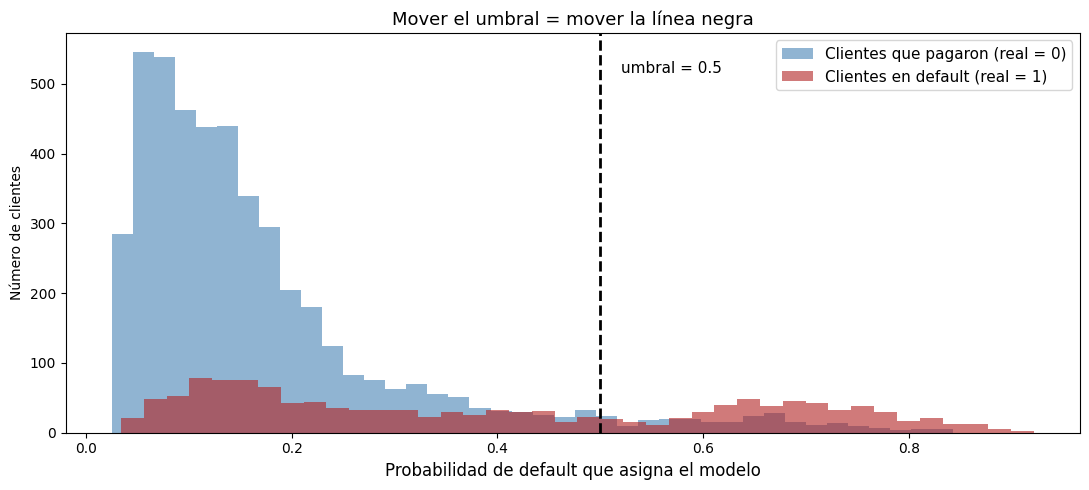

Como las dos montañas se solapan, ningún umbral separa perfecto:
de ahí nace el trade-off que dibuja la curva ROC.


In [28]:
# ── Las probabilidades del modelo, separadas por clase real ──────────────────
# y_prob_rf[y_test == 0] usa una "máscara booleana": (y_test == 0) es una lista
# de True/False, y con ella nos quedamos solo con las probabilidades de los
# clientes que SÍ pagaron. Igual para los que hicieron default.
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(y_prob_rf[y_test == 0], bins=40, alpha=0.6, color='steelblue',
        label='Clientes que pagaron (real = 0)')
ax.hist(y_prob_rf[y_test == 1], bins=40, alpha=0.6, color='firebrick',
        label='Clientes en default (real = 1)')

ax.axvline(0.5, color='black', ls='--', lw=2)                 # el umbral
ax.text(0.52, ax.get_ylim()[1]*0.9, 'umbral = 0.5', fontsize=11)
ax.set_xlabel('Probabilidad de default que asigna el modelo', fontsize=12)
ax.set_ylabel('Número de clientes')
ax.set_title('Mover el umbral = mover la línea negra', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Como las dos montañas se solapan, ningún umbral separa perfecto:")
print("de ahí nace el trade-off que dibuja la curva ROC.")

### Cada umbral es un punto de la curva ROC

Para cada umbral calculamos dos cosas:

- **Recall (TPR):** de los que **sí** hicieron default, ¿qué fracción detectamos? — *queremos que suba*.
- **FPR:** de los que **no** hicieron default, ¿a cuántos acusamos falsamente? — *queremos que baje*.

Al **bajar** el umbral atrapamos más defaults (recall sube) pero también más falsas alarmas (FPR sube). La curva ROC dibuja ese recorrido.


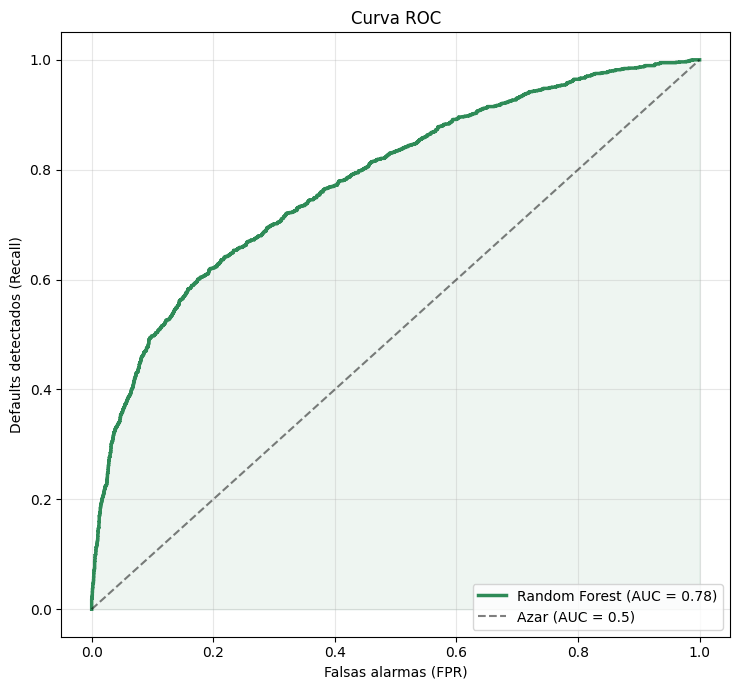

AUC del modelo: 0.779
Cuanto mayor sea el AUC, mejor discrimina el modelo.


In [29]:
# Calculamos la curva ROC y el AUC del modelo.
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Creamos la figura.
fig, ax = plt.subplots(figsize=(7.5, 7))

# Dibujamos la curva ROC.
ax.plot(fpr, tpr, color='seagreen', lw=2.5,
        label=f'Random Forest (AUC = {auc_rf:.2f})')

# Línea de referencia de un clasificador aleatorio.
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar (AUC = 0.5)')

# Rellenamos el área bajo la curva.
ax.fill_between(fpr, tpr, alpha=0.08, color='seagreen')

# Etiquetas y formato.
ax.set_xlabel('Falsas alarmas (FPR)')
ax.set_ylabel('Defaults detectados (Recall)')
ax.set_title('Curva ROC')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Mostramos el valor del AUC.
print(f"AUC del modelo: {auc_rf:.3f}")
print("Cuanto mayor sea el AUC, mejor discrimina el modelo.")

---
## Paso 11 — XGBoost: el tercer modelo

Random Forest construye árboles **en paralelo e independientes** y luego promedia (*bagging*). **XGBoost** usa **boosting**:

> los árboles se construyen **en secuencia**, y cada árbol nuevo se especializa en corregir **los errores del anterior**.

| | Random Forest (bagging) | XGBoost (boosting) |
|---|---|---|
| Cómo crecen los árboles | En paralelo, independientes | En secuencia, corrigiendo al previo |
| Árboles típicos | Profundos | Poco profundos (depth 3–6) |
| Combate sobre todo | La **varianza** | El **sesgo** |

Para datos tabulares como este, XGBoost suele ser uno de los modelos más potentes. Lo entrenamos y lo comparamos.


In [30]:
# XGBoost no viene con scikit-learn: lo instalamos aparte.
# %%capture oculta el texto largo de la instalación.
%%capture
!pip install xgboost

In [31]:
from xgboost import XGBClassifier

# XGBoost también está hecho de árboles, pero los arma EN SECUENCIA: cada árbol
# nuevo corrige los errores del anterior. Por eso usa árboles poco profundos
# (max_depth pequeño) pero muchos.
xgb_clf = XGBClassifier(
    n_estimators     = 400,       # número de rondas (árboles) — más que en RF
    max_depth        = 3,         # árboles poco profundos (típico de boosting)
    learning_rate    = 0.05,      # cuánto aporta cada árbol nuevo (pasos chiquitos)
    subsample        = 0.8,       # cada árbol usa 80% de las filas (algo de azar)
    colsample_bytree = 0.8,       # y 80% de las columnas
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1
)
xgb_clf.fit(X_train, y_train)     # tampoco necesita escalado

print("XGBoost entrenado ✓")

XGBoost entrenado ✓


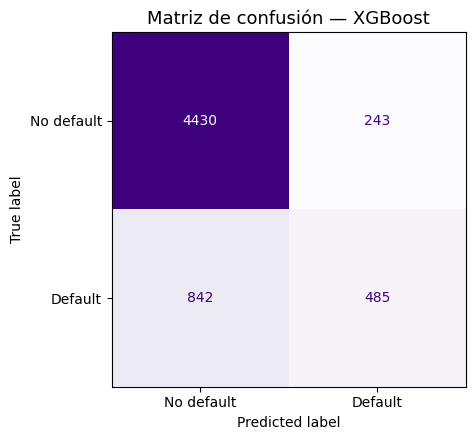

F1 (default) — XGBoost: 0.472


In [32]:
# ── Evaluar XGBoost (misma receta que Random Forest) ─────────────────────────
y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix = confusion_matrix(y_test, y_pred_xgb),
    display_labels   = ['No default', 'Default']
).plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Matriz de confusión — XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

f1_xgb = f1_score(y_test, y_pred_xgb)
print(f"F1 (default) — XGBoost: {f1_xgb:.3f}")

---
## Paso 12 — Comparar los tres modelos

Ya tenemos Lasso, Random Forest y XGBoost. Los comparamos de la forma más simple: con **una sola métrica, el F1** (que resume precision y recall), y con la **curva ROC** de los tres juntos.


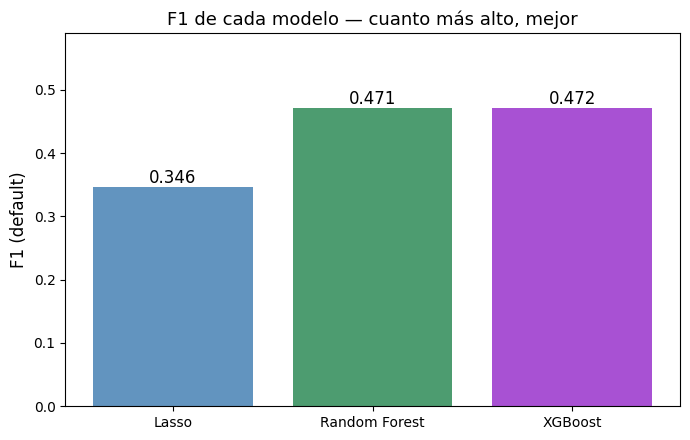

Los tres F1 se parecen bastante. Según esta métrica, los modelos son casi iguales.


In [33]:
# ── F1 de los tres modelos ───────────────────────────────────────────────────
# Guardamos los resultados en un DICCIONARIO {clave: valor}: la clave es el
# nombre del modelo y el valor es su F1.
f1_por_modelo = {
    'Lasso'        : f1_score(y_test, y_pred_lasso),
    'Random Forest': f1_score(y_test, y_pred_rf),
    'XGBoost'      : f1_score(y_test, y_pred_xgb),
}

fig, ax = plt.subplots(figsize=(7, 4.5))
# .keys() saca los nombres y .values() saca los números del diccionario.
barras = ax.bar(list(f1_por_modelo.keys()), list(f1_por_modelo.values()),
                color=['steelblue', 'seagreen', 'darkorchid'], alpha=0.85)
ax.bar_label(barras, fmt='%.3f', fontsize=12)      # escribe el número encima de cada barra
ax.set_ylabel('F1 (default)', fontsize=12)
ax.set_title('F1 de cada modelo — cuanto más alto, mejor', fontsize=13)
ax.set_ylim(0, max(f1_por_modelo.values()) * 1.25)
plt.tight_layout()
plt.show()

print("Los tres F1 se parecen bastante. Según esta métrica, los modelos son casi iguales.")

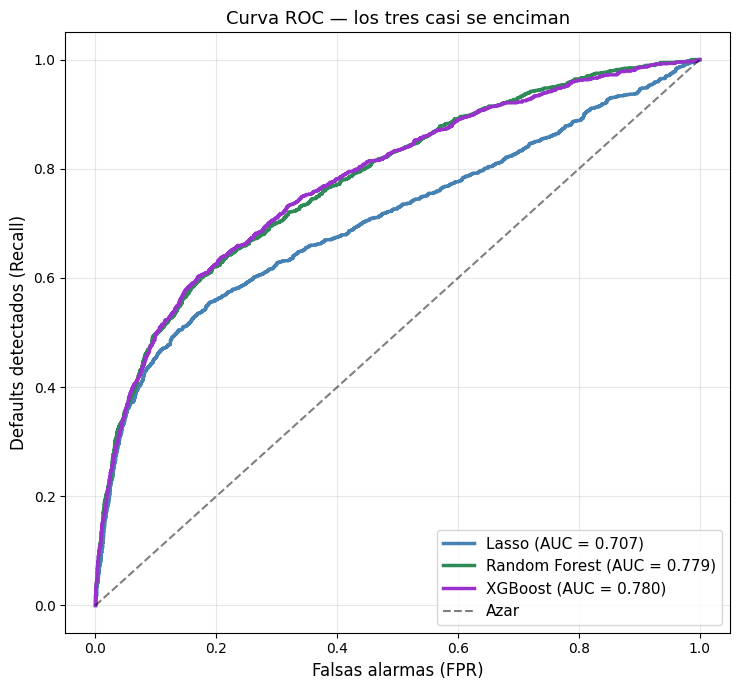

Random Forest y XGBoost dan curvas casi idénticas: separan igual de bien.
Entonces... ¿en qué se diferencian? Lo vemos en el Paso 13.


In [34]:
# ── Curva ROC de los tres modelos ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 7))

# Lista de TUPLAS (nombre, probabilidades, color). La recorremos con un for.
modelos_roc = [
    ('Lasso',         y_prob_lasso, 'steelblue'),
    ('Random Forest', y_prob_rf,    'seagreen'),
    ('XGBoost',       y_prob_xgb,   'darkorchid'),
]
for nombre, prob, color in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, prob)     # el _ ignora el tercer valor (los umbrales)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{nombre} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar')
ax.set_xlabel('Falsas alarmas (FPR)', fontsize=12)
ax.set_ylabel('Defaults detectados (Recall)', fontsize=12)
ax.set_title('Curva ROC — los tres casi se enciman', fontsize=13)
ax.legend(fontsize=11, loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Random Forest y XGBoost dan curvas casi idénticas: separan igual de bien.")
print("Entonces... ¿en qué se diferencian? Lo vemos en el Paso 13.")

---
## Paso 13 — Random Forest vs XGBoost: ¿en qué se diferencian?

Acabamos de ver que Random Forest y XGBoost tienen **F1 parecido** y **curvas ROC casi idénticas**. ¿Son iguales entonces? **No.** La diferencia no está en *a quién clasifican*, sino en *qué tan confiables son las probabilidades* que producen.

El paper que originó esta base de datos (**Yeh & Lien, 2009**) defiende justo esta idea: para un banco, lo valioso no es el "sí/no", sino la **probabilidad real de default**. Un cliente con 90% de probabilidad no es lo mismo que uno con 51%, aunque a ambos se les clasifique como "default".



Predicciones confiadas (probabilidad <10% o >90%):
  Random Forest: 29.9%
  XGBoost:       30.6%


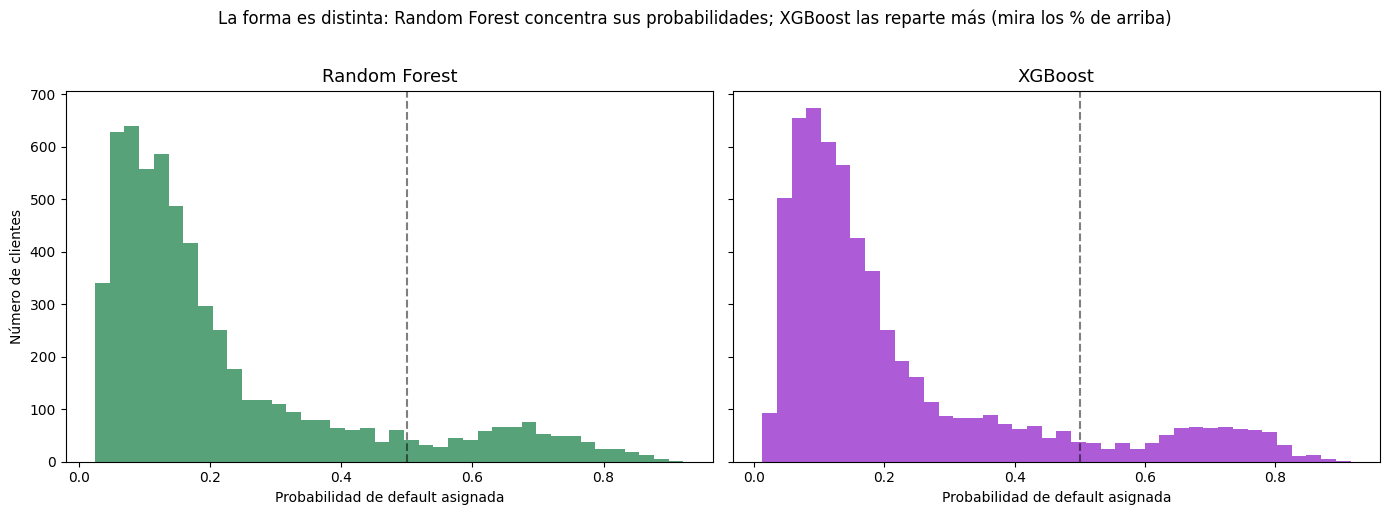

In [35]:
# ── ¿Qué tan seguro se atreve a estar cada modelo? ───────────────────────────
# Una FUNCIÓN que mide qué fracción de predicciones son "confiadas" (muy cerca
# de 0 o de 1). (prob < 0.1) da una lista de True/False; .mean() de esa lista
# es la proporción de True (Python cuenta True como 1 y False como 0).
def fraccion_confiada(prob):
    return ((prob < 0.1) | (prob > 0.9)).mean()    # | es "o" elemento por elemento

print("Predicciones confiadas (probabilidad <10% o >90%):")
print(f"  Random Forest: {fraccion_confiada(y_prob_rf):.1%}")
print(f"  XGBoost:       {fraccion_confiada(y_prob_xgb):.1%}")

# Dibujamos la distribución de las probabilidades de cada modelo, lado a lado.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, prob, nombre, color in [(ax1, y_prob_rf,  'Random Forest', 'seagreen'),
                                (ax2, y_prob_xgb, 'XGBoost',       'darkorchid')]:
    ax.hist(prob, bins=40, color=color, alpha=0.8)
    ax.set_title(nombre, fontsize=13)
    ax.set_xlabel('Probabilidad de default asignada')
    ax.axvline(0.5, color='black', ls='--', alpha=0.5)
ax1.set_ylabel('Número de clientes')
fig.suptitle('La forma es distinta: Random Forest concentra sus probabilidades; '
             'XGBoost las reparte más (mira los % de arriba)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()